<a href="https://colab.research.google.com/github/tjdux/pandas-for-finance/blob/main/01_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Series 만드는 방법

In [1]:
import pandas as pd

In [2]:
# Data Type: list
ls1= [1, 2, 3, 4, 5, 6, 7, 8, 9]
ls2 = [1, 2, 3, "Apple", "play", 6, 7, 8, 9]

sr1 = pd.Series(ls1)
sr1

sr2 = pd.Series(ls2)
sr2

,0
0,1
1,2
2,3
3,Apple
4,play
5,6
6,7
7,8
8,9


In [3]:
# Series에 Name 설정
sr1.name = "Number"
sr2.name = "Word"
sr1

,Number
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9


In [4]:
# DataType: dictionary
dic1 = {"a": 1, "b": 2, "c": 3}
sr3 = pd.Series(dic1)
sr3.name = "Number"
sr3

,Number
a,1
b,2
c,3


## CSV 파일을 Series로 불러오기

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
file_path = "/content/drive/MyDrive/financial pandas/삼성전자 종가.csv"
df = pd.read_csv(file_path, index_col=0, header=0)
samsung_price = df.squeeze(axis=1) # DataFrame -> Series
type(samsung_price)

pandas.core.series.Series

## Index & Value

In [7]:
samsung_price.index

Index(['2018-01-02', '2018-01-03', '2018-01-04', '2018-01-05', '2018-01-08',
       '2018-01-09', '2018-01-10', '2018-01-11', '2018-01-12', '2018-01-15',
       ...
       '2021-12-06', '2021-12-07', '2021-12-08', '2021-12-09', '2021-12-10',
       '2021-12-13', '2021-12-14', '2021-12-15', '2021-12-16', '2021-12-17'],
      dtype='object', name='Date', length=977)

In [8]:
# 2020-12-15 데이터가 있을까?
print('2020-12-15' in samsung_price.index)
print(samsung_price.loc['2020-12-15'])

True
73800


In [9]:
# 100번째 Data값?
print(samsung_price.iloc[100])

49500


## 새로운 값 추가

In [10]:
# samsung_price의 총 길이?
print(samsung_price.shape)
print(f"마지막 인덱스: {samsung_price.index[samsung_price.shape[0]-1]}")

(977,)
마지막 인덱스: 2021-12-17


In [11]:
# 2021-12-20 가격 업데이트
samsung_price.loc["2021-12-20"] = 77100
samsung_price.tail()

,Close
Date,
2021-12-14,77000
2021-12-15,77600
2021-12-16,77800
2021-12-17,78000
2021-12-20,77100


## 두 개의 Series 연결하기

In [12]:
file_path = "/content/drive/MyDrive/financial pandas/samsung_excel.xlsx"
series1_samsung = pd.read_excel(file_path, index_col=0, header=0,
                                sheet_name="Sheet1").squeeze()
series2_samsung = pd.read_excel(file_path, index_col=0, header=0,
                                sheet_name="Sheet2").squeeze()
series_samsung = pd.concat([series1_samsung, series2_samsung], ignore_index=False)
series_samsung

,Close
Date,
2018-01-02,51020
2018-01-03,51620
2018-01-04,51080
2018-01-05,52120
2018-01-08,52020
...,...
2021-12-20,77100
2021-12-21,78100
2021-12-22,79400


## 기본 통계치 구하기

In [13]:
print(f"고점: {samsung_price.max()}")
print(f"저점: {samsung_price.min()}")

고점: 91000
저점: 37450


In [14]:
samsung_price.describe()

,Close
count,978.000000
mean,57316.104294
std,14091.429092
min,37450.000000
25%,46300.000000
50%,51300.000000
75%,70200.000000
max,91000.000000


In [15]:
# 고점인 날짜
print(f"{samsung_price.index[samsung_price.values == samsung_price.max()]}")
print(f"{samsung_price.index[samsung_price.argmax()]}")
print(f"{samsung_price.iloc[samsung_price.argmax()]}")

Index(['2021-01-11'], dtype='object', name='Date')
2021-01-11
91000


## Series 연산

In [16]:
samsung_price.shift().head()

,Close
Date,
2018-01-02,NaN
2018-01-03,51020.0
2018-01-04,51620.0
2018-01-05,51080.0
2018-01-08,52120.0


In [17]:
# 삼성전자 수익률
samsung_return = (samsung_price - samsung_price.shift()) / samsung_price.shift()
samsung_return.head()

,Close
Date,
2018-01-02,NaN
2018-01-03,0.011760
2018-01-04,-0.010461
2018-01-05,0.020360
2018-01-08,-0.001919


In [18]:
samsung_price.pct_change().head()

,Close
Date,
2018-01-02,NaN
2018-01-03,0.011760
2018-01-04,-0.010461
2018-01-05,0.020360
2018-01-08,-0.001919


In [19]:
# 수익률이 제일 높은 날짜
samsung_return.index[samsung_return.argmax()]

'2020-03-24'

## NaN값 처리
- NaN값 제거: `dropna()`
- NaN값 채우기: `fillna()`
- NaN값 연산: 결과 `NaN`

In [20]:
samsung_return.head()

,Close
Date,
2018-01-02,NaN
2018-01-03,0.011760
2018-01-04,-0.010461
2018-01-05,0.020360
2018-01-08,-0.001919


In [21]:
samsung_return.dropna().head()

,Close
Date,
2018-01-03,0.011760
2018-01-04,-0.010461
2018-01-05,0.020360
2018-01-08,-0.001919
2018-01-09,-0.031142


In [22]:
samsung_return.fillna(0).head()

,Close
Date,
2018-01-02,0.000000
2018-01-03,0.011760
2018-01-04,-0.010461
2018-01-05,0.020360
2018-01-08,-0.001919


## 순서대로 정렬
- `sort_values(ascending=True or False)`
- `sort_index(ascending=True or False)`

In [23]:
samsung_price.sort_index(ascending=False).head()

,Close
Date,
2021-12-20,77100
2021-12-17,78000
2021-12-16,77800
2021-12-15,77600
2021-12-14,77000


In [24]:
samsung_price.sort_values().head()

,Close
Date,
2019-01-04,37450
2019-01-03,37600
2019-01-08,38100
2018-12-27,38250
2018-12-26,38350


In [25]:
samsung_price.sort_values(ascending=False).head(1)

,Close
Date,
2021-01-11,91000


## 특정 조건에 맞는 값을 찾고 싶을 때
- `Series.values or index [조건]`

In [26]:
import numpy as np

In [27]:
samsung_return_percentage = samsung_return * 100
samsung_return_percentage.head()

,Close
Date,
2018-01-02,NaN
2018-01-03,1.176009
2018-01-04,-1.046106
2018-01-05,2.036022
2018-01-08,-0.191865


In [28]:
samsung_return_percentage[samsung_return_percentage.values >= 4]

,Close
Date,
2018-03-06,4.026549
2018-09-14,4.086266
2018-11-02,4.744958
2019-03-21,4.086266
2020-03-20,5.704307
2020-03-24,10.470588
2020-04-17,4.897959
2020-06-03,6.031128
2020-06-16,4.408818


In [29]:
samsung_return_percentage.index[samsung_return_percentage.values >= 4]

Index(['2018-03-06', '2018-09-14', '2018-11-02', '2019-03-21', '2020-03-20',
       '2020-03-24', '2020-04-17', '2020-06-03', '2020-06-16', '2020-07-28',
       '2020-11-16', '2020-11-23', '2020-12-24', '2021-01-08', '2021-02-25',
       '2021-11-22', '2021-12-01'],
      dtype='object', name='Date')

In [30]:
samsung_return_percentage[samsung_return_percentage.values >= 4]
sum(samsung_return_percentage.values >= 4)

np.int64(17)

In [31]:
samsung_return_over_4 = pd.Series(np.where(samsung_return_percentage.values >= 4, 1, 0))
samsung_return_over_4.index = samsung_return.index
samsung_return_over_4

,0
Date,
2018-01-02,0
2018-01-03,0
2018-01-04,0
2018-01-05,0
2018-01-08,0
...,...
2021-12-14,0
2021-12-15,0
2021-12-16,0


## Series Rolling


In [32]:
# 30일 이동평균선 구하기
samsung_price.rolling(window=30).mean()

,Close
Date,
2018-01-02,NaN
2018-01-03,NaN
2018-01-04,NaN
2018-01-05,NaN
2018-01-08,NaN
...,...
2021-12-14,73273.333333
2021-12-15,73513.333333
2021-12-16,73753.333333


<Axes: xlabel='Date'>

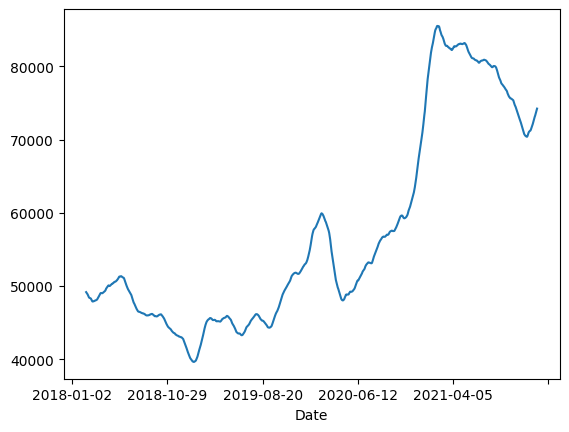

In [33]:
samsung_price.rolling(window=30).mean().plot()

## Series 구간 나누기
- `pd.cut(series, bins=)`: `bins`의 개수로 구간을 나눔
- `pd.qcut(series)`: 동일한 개수로 구간을 나눔

In [36]:
pd.cut(samsung_return, bins=10)

,Close
Date,
2018-01-02,NaN
2018-01-03,"(0.00356, 0.0204]"
2018-01-04,"(-0.0133, 0.00356]"
2018-01-05,"(0.00356, 0.0204]"
2018-01-08,"(-0.0133, 0.00356]"
...,...
2021-12-14,"(-0.0133, 0.00356]"
2021-12-15,"(0.00356, 0.0204]"
2021-12-16,"(-0.0133, 0.00356]"


In [37]:
pd.cut(samsung_return, bins=10).value_counts()

,count
Close,
"(-0.0133, 0.00356]",415
"(0.00356, 0.0204]",298
"(-0.0302, -0.0133]",137
"(0.0204, 0.0373]",70
"(-0.047, -0.0302]",31
"(0.0373, 0.0541]",19
"(-0.064, -0.047]",3
"(0.0541, 0.071]",2
"(0.071, 0.0878]",1


In [39]:
pd.qcut(samsung_return, 10).value_counts()

,count
Close,
"(-0.00333, 0.0]",109
"(-0.0649, -0.0194]",98
"(-0.0194, -0.0116]",98
"(-0.00706, -0.00333]",98
"(0.0122, 0.02]",98
"(0.00351, 0.00752]",98
"(0.02, 0.105]",98
"(-0.0116, -0.00706]",97
"(0.00752, 0.0122]",97


## 서로 다른 두 개의 Series 연산
- **Series는 index를 기준으로 계산!!**

In [52]:
kospi = pd.read_csv("/content/drive/MyDrive/financial pandas/KOSPI.csv", index_col=0, header=0).squeeze()
kospi

,Close
Date,
2020-01-02,2175.17
2020-01-03,2176.46
2020-01-06,2155.07
2020-01-07,2175.54
2020-01-08,2151.31
...,...
2021-12-13,3001.66
2021-12-14,2987.95
2021-12-15,2989.39


In [53]:
print(f"samsung_price.shape: {samsung_price.shape}")
print(f"kospi.shape: {kospi.shape}")

samsung_price.shape: (978,)
kospi.shape: (477,)


In [54]:
samsung = samsung_price.loc["2020-01-02":]
samsung

,Close
Date,
2020-01-02,55200
2020-01-03,55500
2020-01-06,55500
2020-01-07,55800
2020-01-08,56800
...,...
2021-12-14,77000
2021-12-15,77600
2021-12-16,77800


In [55]:
samsung = samsung.loc[kospi.index]
samsung.shape

(477,)

In [56]:
samsung.corr(kospi)

np.float64(0.95839711328083)